# Orchestrator–worker pattern

An **orchestrator** receives the user’s task, breaks it into subtasks, and dispatches **parallel workers**—each tuned for a specific domain. When every worker has finished, a **summarizer** merges their outputs into a single coherent result.

## Why use it

Specialized workers are easier to improve in isolation: you can change prompts, tools, or models for one role without rewriting the whole system. Parallel execution also shortens wall-clock time when subtasks are independent.

**Flow (this notebook)**

```text
                    +---------------------------+
                    | research_assistant_agent  |
                    | (search + orchestration)  |
                    +-------------+-------------+
                                  |
            +---------------------+---------------------+
            |                     |                     |
            v                     v                     v
   +----------------+   +----------------+   +----------------+
   | summary_writer |   |  body_writer   |   | conclusion_    |
   |   (worker)     |   |   (worker)     |   | writer(worker) |
   +--------+-------+   +--------+-------+   +--------+-------+
            |                     |                     |
            +---------------------+---------------------+
                                  |
                                  v
                    +---------------------------+
                    | research_report_aggregator|
                    +---------------------------+
```

Requires `GEMINI_API_KEY` and `SERPER_API_KEY` in `.env` for the model and Google Serper search.

### Step 1: Imports and model setup

This cell loads environment variables and initializes a single chat model (Gemini via `google_genai`) that every node will share. The model name comes from `GEMINI_MODEL`, with an optional `models/` prefix stripped for compatibility.

In [1]:
import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

raw_model_name = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")
model_name = raw_model_name.replace("models/", "", 1)

llm = init_chat_model(
    model=model_name,
    model_provider="google_genai",
    api_key=os.getenv("GEMINI_API_KEY"),
)

### Step 2: Graph state (`ResearchReport`)

This cell defines the shared `TypedDict` state for the LangGraph:

- **`title`**: research topic passed in at invoke time.
- **`summary`**, **`body`**, **`conclusion`**: filled by parallel writer workers.
- **`report_assistant_response`**: list with `Annotated[..., add]` so orchestrator turns can append without overwriting prior entries.
- **`final_report`**: assembled string produced by the aggregator node.

In [2]:
from operator import add
from typing import Annotated

from typing_extensions import TypedDict


class ResearchReport(TypedDict):
    title: str
    summary: str
    body: str
    conclusion: str
    report_assistant_response: Annotated[list[str], add]
    final_report: str

### Step 3: Search tool and orchestrator agent

We wrap **Google Serper** as a LangChain `Tool`, bind it to the LLM (`llm_with_tools`), and implement **`research_assistant_agent`**: the orchestrator that researches the topic (model may call search) and records its reply into `report_assistant_response`.

Run this after Step 1 so `llm` exists.

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import Tool

serper = GoogleSerperAPIWrapper()

tool_search = Tool(
    name="search",
    func=serper.run,
    description="Useful for when you need more information from an online search",
)

llm_with_tools = llm.bind_tools(tool_search)


def research_assistant_agent(state: ResearchReport) -> dict:
    report_assistant_prompt = """You are a research assistant agent who is given a topic. Do research on the topic and return the report.
    Specialized agents will write summary, body, and conclusion."""
    response = llm_with_tools.invoke(
        [
            SystemMessage(content=report_assistant_prompt),
            HumanMessage(
                content="Do research on the topic and return the result in raw text: "
                + state["title"]
            ),
        ]
    )
    text = getattr(response, "content", None) or str(response)
    return {"report_assistant_response": [text]}

convert_to_genai_function_declarations expects a Sequence and not a single tool.


### Step 4: Parallel worker nodes (summary, body, conclusion)

Three **specialist** nodes each call the same base `llm` with a different system prompt. They only need the topic (`state["title"]`) here; in a richer pipeline you could pass the orchestrator’s research text into these prompts.

LangGraph runs these nodes **in parallel** after the orchestrator because they share the same upstream edge (see Step 5).

In [4]:
def research_report_summary_writer(state: ResearchReport) -> dict:
    prompt = """You are a research report summary writer. You are given a topic; write a concise summary for the report."""
    out = llm.invoke(
        [
            SystemMessage(content=prompt),
            HumanMessage(content="Write a summary of the report: " + state["title"]),
        ]
    )
    return {"summary": getattr(out, "content", None) or str(out)}


def research_report_body_writer(state: ResearchReport) -> dict:
    prompt = """You are a research report body writer. You are given a topic; write the main body of the report."""
    out = llm.invoke(
        [
            SystemMessage(content=prompt),
            HumanMessage(content="Write the body of the report: " + state["title"]),
        ]
    )
    return {"body": getattr(out, "content", None) or str(out)}


def research_report_conclusion_writer(state: ResearchReport) -> dict:
    prompt = """You are a research report conclusion writer. You are given a topic; write the conclusion of the report."""
    out = llm.invoke(
        [
            SystemMessage(content=prompt),
            HumanMessage(content="Write a conclusion for the report: " + state["title"]),
        ]
    )
    return {"conclusion": getattr(out, "content", None) or str(out)}

### Step 5: Aggregator, graph wiring, and compile

- **`research_report_aggregator`**: concatenates `title`, `summary`, `body`, and `conclusion` into `final_report`.
- **`StateGraph`**: registers nodes and edges. From `research_assistant_agent`, **three edges** fan out to the writers; each writer connects to the aggregator, which then goes to `END`.
- **`compile()`** produces the runnable `app`.

Ensure Steps 2–4 have been executed so all node functions and `ResearchReport` exist.

In [5]:
from langgraph.graph import END, START, StateGraph


def research_report_aggregator(state: ResearchReport) -> dict:
    final_report = f"""
Title: {state["title"]}
Summary: {state["summary"]}
Body: {state["body"]}
Conclusion: {state["conclusion"]}
"""
    return {"final_report": final_report.strip()}


parallel_builder = StateGraph(ResearchReport)

parallel_builder.add_node("research_assistant_agent", research_assistant_agent)
parallel_builder.add_node("research_report_summary_writer", research_report_summary_writer)
parallel_builder.add_node("research_report_body_writer", research_report_body_writer)
parallel_builder.add_node("research_report_conclusion_writer", research_report_conclusion_writer)
parallel_builder.add_node("research_report_aggregator", research_report_aggregator)

parallel_builder.add_edge(START, "research_assistant_agent")
parallel_builder.add_edge("research_assistant_agent", "research_report_summary_writer")
parallel_builder.add_edge("research_assistant_agent", "research_report_body_writer")
parallel_builder.add_edge("research_assistant_agent", "research_report_conclusion_writer")
parallel_builder.add_edge("research_report_summary_writer", "research_report_aggregator")
parallel_builder.add_edge("research_report_body_writer", "research_report_aggregator")
parallel_builder.add_edge("research_report_conclusion_writer", "research_report_aggregator")
parallel_builder.add_edge("research_report_aggregator", END)

app = parallel_builder.compile()

### Step 6: Visualize the graph and run a topic

Render a Mermaid diagram of the compiled graph, then **`app.invoke`** with a full initial state (all keys required by the `TypedDict`). The printed **`final_report`** is the merged output from the aggregator.

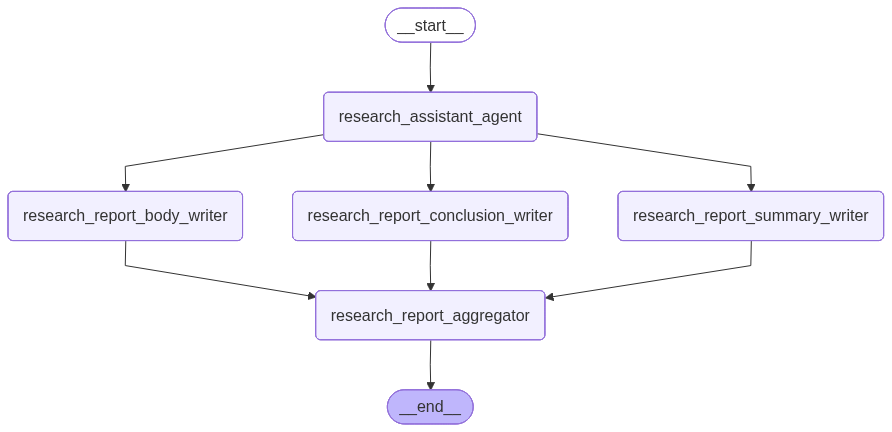

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring


In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

initial = {
    "title": "The impact of AI on the future of work",
    "summary": "",
    "body": "",
    "conclusion": "",
    "report_assistant_response": [],
    "final_report": "",
}
result = app.invoke(initial)
print(result["final_report"])